# 01 - Khám phá dữ liệu (EDA)
BTL môn Trí tuệ nhân tạo — Dự đoán khả năng Đỗ/Trượt của sinh viên

## Bước 1: Đọc dữ liệu

In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/Expanded_data_with_more_features.csv")
df.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


## Bước 2: Xem thông tin tổng quan

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  str    
 2   EthnicGroup          28801 non-null  str    
 3   ParentEduc           28796 non-null  str    
 4   LunchType            30641 non-null  str    
 5   TestPrep             28811 non-null  str    
 6   ParentMaritalStatus  29451 non-null  str    
 7   PracticeSport        30010 non-null  str    
 8   IsFirstChild         29737 non-null  str    
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  str    
 11  WklyStudyHours       29686 non-null  str    
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), str(10)
memory usage: 

In [3]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [4]:
df.shape

(30641, 15)

## Bước 3: Kiểm tra dữ liệu thiếu

In [5]:
df.isnull().sum()

Unnamed: 0                0
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

## Bước 4: Vẽ biểu đồ khám phá dữ liệu

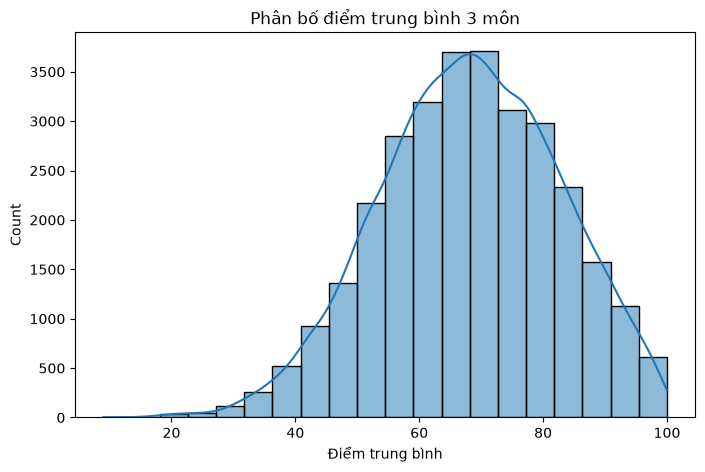

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../results/figures", exist_ok=True)

# Tạo tạm cột điểm trung bình chỉ để xem phân bố (chưa lưu vào file xử lý)
df['AvgScore_temp'] = df[['MathScore', 'ReadingScore', 'WritingScore']].mean(axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(df['AvgScore_temp'], bins=20, kde=True)
plt.title("Phân bố điểm trung bình 3 môn")
plt.xlabel("Điểm trung bình")
plt.savefig("../results/figures/phan_bo_diem.png")
plt.show()

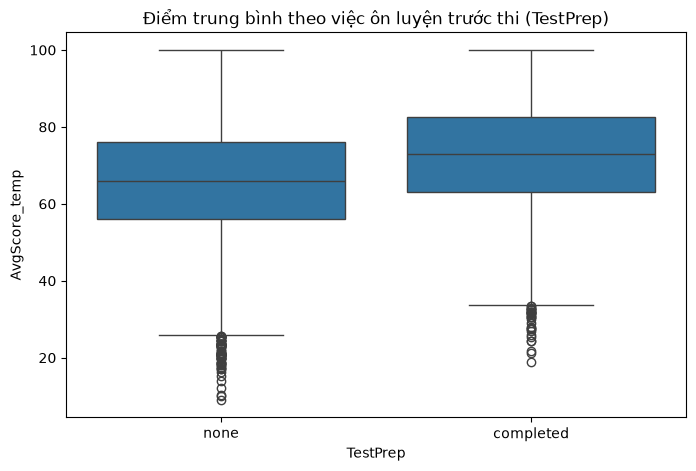

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='TestPrep', y='AvgScore_temp')
plt.title("Điểm trung bình theo việc ôn luyện trước thi (TestPrep)")
plt.savefig("../results/figures/diem_theo_testprep.png")
plt.show()

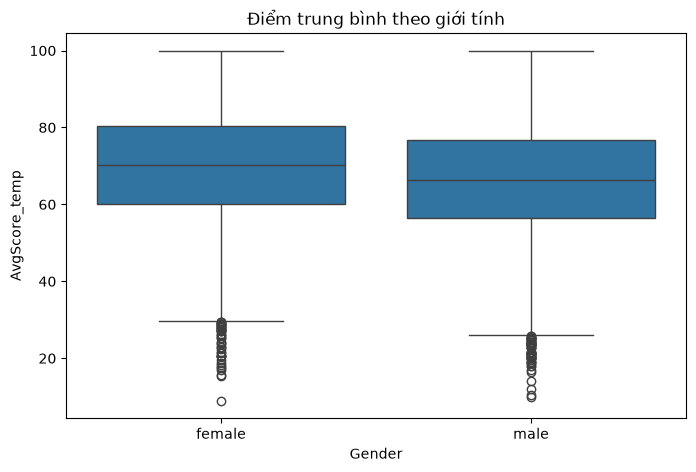

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='AvgScore_temp')
plt.title("Điểm trung bình theo giới tính")
plt.savefig("../results/figures/diem_theo_gioitinh.png")
plt.show()

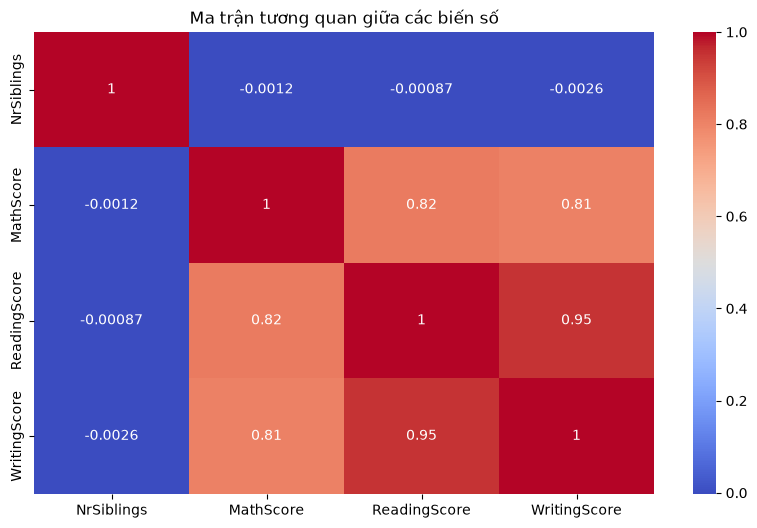

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[['NrSiblings', 'MathScore', 'ReadingScore', 'WritingScore']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Ma trận tương quan giữa các biến số")
plt.savefig("../results/figures/correlation_heatmap.png")
plt.show()

## Bước 5: Xóa cột tạm (không cần lưu ở bước EDA này)

In [10]:
df = df.drop(columns=['AvgScore_temp'])
print("Đã xong bước khám phá dữ liệu. Chuyển sang notebook 02_preprocessing.ipynb")

Đã xong bước khám phá dữ liệu. Chuyển sang notebook 02_preprocessing.ipynb
